### **Sanskrit Handwritten Character Classification using Multi-Class Logistic Regression**

Step 1— Connect Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 2 — Import Libraries

In [3]:
import os
import io
import zipfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

STEP 3 — Give Dataset Path

In [4]:
ZIP_PATH = "/content/drive/MyDrive/CIS/devanagari+handwritten+character+dataset.zip"

print("Dataset found:", os.path.exists(ZIP_PATH))

Dataset found: True


In [5]:
zip_file = zipfile.ZipFile(ZIP_PATH, 'r')

all_files = zip_file.namelist()

print("Total files:", len(all_files))

Total files: 92095


STEP 5 — Find Images

In [6]:
png_files = [
    file for file in all_files
    if file.lower().endswith(".png")
]

print("Total PNG images:", len(png_files))

Total PNG images: 92000


STEP 6 — Separate Train & Test

In [7]:
train_files = [
    file for file in png_files
    if "Train" in file
]

test_files = [
    file for file in png_files
    if "Test" in file
]

print("Training images:", len(train_files))
print("Testing images:", len(test_files))

Training images: 78200
Testing images: 13800


Step 7-Find Character Classes

In [8]:
def get_class_name(file_name):
    return file_name.strip("/").split("/")[-2]

classes = sorted(
    set(get_class_name(file) for file in png_files)
)

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 46
Classes: ['character_10_yna', 'character_11_taamatar', 'character_12_thaa', 'character_13_daa', 'character_14_dhaa', 'character_15_adna', 'character_16_tabala', 'character_17_tha', 'character_18_da', 'character_19_dha', 'character_1_ka', 'character_20_na', 'character_21_pa', 'character_22_pha', 'character_23_ba', 'character_24_bha', 'character_25_ma', 'character_26_yaw', 'character_27_ra', 'character_28_la', 'character_29_waw', 'character_2_kha', 'character_30_motosaw', 'character_31_petchiryakha', 'character_32_patalosaw', 'character_33_ha', 'character_34_chhya', 'character_35_tra', 'character_36_gya', 'character_3_ga', 'character_4_gha', 'character_5_kna', 'character_6_cha', 'character_7_chha', 'character_8_ja', 'character_9_jha', 'digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


Step 8 -Create Numerical Labels

In [9]:
class_to_id = {
    class_name: index
    for index, class_name in enumerate(classes)
}

id_to_class = {
    index: class_name
    for class_name, index in class_to_id.items()
}

print(class_to_id)

{'character_10_yna': 0, 'character_11_taamatar': 1, 'character_12_thaa': 2, 'character_13_daa': 3, 'character_14_dhaa': 4, 'character_15_adna': 5, 'character_16_tabala': 6, 'character_17_tha': 7, 'character_18_da': 8, 'character_19_dha': 9, 'character_1_ka': 10, 'character_20_na': 11, 'character_21_pa': 12, 'character_22_pha': 13, 'character_23_ba': 14, 'character_24_bha': 15, 'character_25_ma': 16, 'character_26_yaw': 17, 'character_27_ra': 18, 'character_28_la': 19, 'character_29_waw': 20, 'character_2_kha': 21, 'character_30_motosaw': 22, 'character_31_petchiryakha': 23, 'character_32_patalosaw': 24, 'character_33_ha': 25, 'character_34_chhya': 26, 'character_35_tra': 27, 'character_36_gya': 28, 'character_3_ga': 29, 'character_4_gha': 30, 'character_5_kna': 31, 'character_6_cha': 32, 'character_7_chha': 33, 'character_8_ja': 34, 'character_9_jha': 35, 'digit_0': 36, 'digit_1': 37, 'digit_2': 38, 'digit_3': 39, 'digit_4': 40, 'digit_5': 41, 'digit_6': 42, 'digit_7': 43, 'digit_8': 4

STEP 9 — Preprocess the Images

In [10]:
def load_images_from_zip(file_list):

    X = []
    y = []

    for file_name in file_list:

        image_data = zip_file.read(file_name)

        image = Image.open(
            io.BytesIO(image_data)
        ).convert("L")

        image = image.resize((32, 32))

        image_array = np.array(image) / 255.0

        image_array = image_array.flatten()

        class_name = get_class_name(file_name)

        label = class_to_id[class_name]

        X.append(image_array)
        y.append(label)

    return np.array(X), np.array(y)

print("Preprocessing function ready!")

Preprocessing function ready!


STEP 10 — Load Training Images

In [11]:
X_train, y_train = load_images_from_zip(train_files)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (78200, 1024)
Training labels shape: (78200,)


STEP 11 — Load Testing Images

In [12]:
X_test, y_test = load_images_from_zip(test_files)

print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Testing data shape: (13800, 1024)
Testing labels shape: (13800,)


STEP 12 — Checking the Dataset

In [13]:
print("Number of classes:", len(classes))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Image size: 32 × 32")
print("Features per image:", X_train.shape[1])

Number of classes: 46
Training samples: 78200
Testing samples: 13800
Image size: 32 × 32
Features per image: 1024


STEP 13 — Show Sample Images

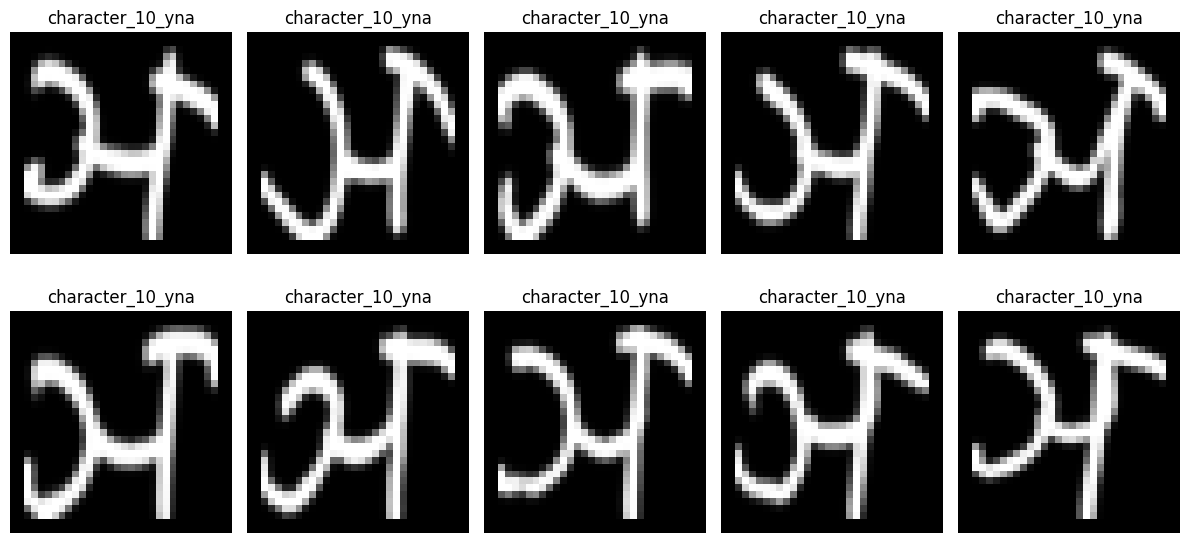

In [14]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = X_train[i].reshape(32, 32)

    plt.imshow(image, cmap="gray")
    plt.title(id_to_class[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 14 — Train the Logistic Regression Model

In [15]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    multi_class="multinomial"
)

model.fit(X_train, y_train)

print("Model training completed!")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model training completed!


STEP 15 — Make Predictions

In [16]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


STEP 16 — Calculate Accuracy

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 73.4 %


STEP 17 — Precision, Recall & F1 Score

In [18]:
precision = precision_score(
    y_test, y_pred, average="weighted"
)

recall = recall_score(
    y_test, y_pred, average="weighted"
)

f1 = f1_score(
    y_test, y_pred, average="weighted"
)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Precision: 0.7323
Recall: 0.734
F1 Score: 0.7325


STEP 18 — Classification Report

In [19]:
report = classification_report(
    y_test,
    y_pred,
    target_names=classes
)

print(report)

                           precision    recall  f1-score   support

         character_10_yna       0.79      0.80      0.79       300
    character_11_taamatar       0.85      0.82      0.83       300
        character_12_thaa       0.79      0.81      0.80       300
         character_13_daa       0.64      0.68      0.66       300
        character_14_dhaa       0.79      0.83      0.81       300
        character_15_adna       0.70      0.69      0.69       300
      character_16_tabala       0.70      0.77      0.73       300
         character_17_tha       0.62      0.59      0.61       300
          character_18_da       0.66      0.66      0.66       300
         character_19_dha       0.72      0.70      0.71       300
           character_1_ka       0.81      0.79      0.80       300
          character_20_na       0.71      0.71      0.71       300
          character_21_pa       0.57      0.68      0.62       300
         character_22_pha       0.80      0.79      0.79     

STEP 19 — Confusion Matrix

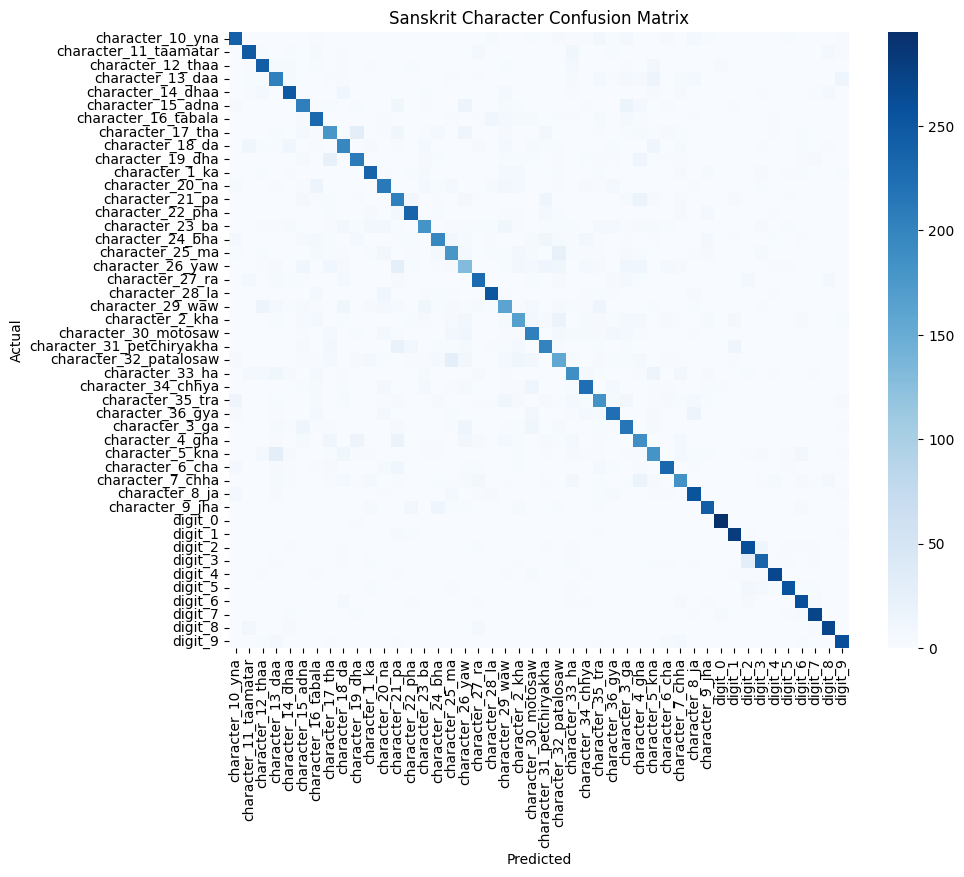

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sanskrit Character Confusion Matrix")
plt.show()

STEP 20 — Compare Actual vs Predicted

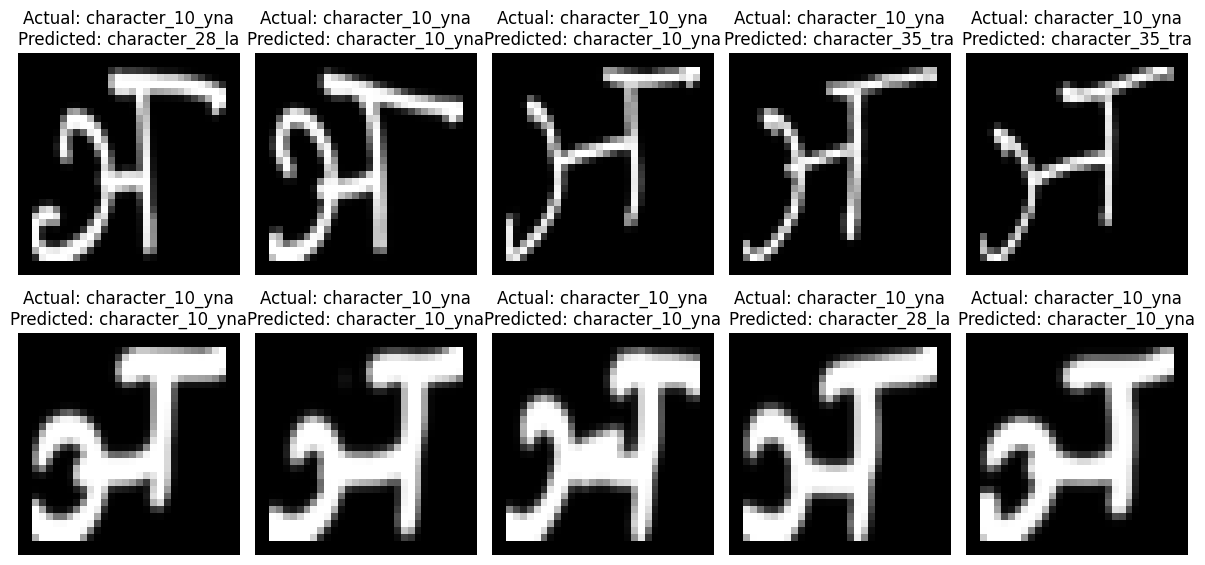

In [20]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = X_test[i].reshape(32, 32)

    plt.imshow(image, cmap="gray")

    actual = id_to_class[y_test[i]]
    predicted = id_to_class[y_pred[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 21 — Prediction Confidence

In [21]:
probabilities = model.predict_proba(X_test[:10])

predicted_classes = model.predict(X_test[:10])

for i in range(10):

    predicted_id = predicted_classes[i]

    confidence = probabilities[i][predicted_id]

    print(
        f"Image {i + 1}: "
        f"{id_to_class[predicted_id]} "
        f"({confidence * 100:.2f}%)"
    )

Image 1: character_28_la (53.99%)
Image 2: character_10_yna (41.09%)
Image 3: character_10_yna (47.79%)
Image 4: character_35_tra (26.01%)
Image 5: character_35_tra (47.61%)
Image 6: character_10_yna (70.01%)
Image 7: character_10_yna (99.55%)
Image 8: character_10_yna (99.97%)
Image 9: character_28_la (49.28%)
Image 10: character_10_yna (81.04%)


In [22]:
print("FINAL RESULTS")

print("Number of Classes:", len(classes))
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))



FINAL RESULTS
Number of Classes: 46
Training Samples: 78200
Testing Samples: 13800
Accuracy: 73.4 %
Precision: 0.7323
Recall: 0.734
F1 Score: 0.7325
